In [9]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

#  데이터 로드
cancer_data = load_breast_cancer()

# Feature DataFrame 생성
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)

#  종속변수(Target) 추가 및 생물학적 레이블 매핑
# Scikit-learn 원본 기준: 0 = 'malignant'(악성), 1 = 'benign'(양성)
df['target_label'] = np.where(cancer_data.target == 0, 'malignant', 'benign')

# 4. 데이터 차원 및 상위 5개 행 구조 확인
print(f"데이터셋 형태(Shape): {df.shape}") 
display(df.head())

데이터셋 형태(Shape): (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [10]:
#  데이터 결측치(Missing Values) 확인
missing_values = df.isnull().sum().sum()
print(f"총 결측치 개수: {missing_values}개")

#  타겟 변수(클래스) 불균형 확인
class_counts = df['target_label'].value_counts()
class_ratios = df['target_label'].value_counts(normalize=True) * 100

print("\n--- 클래스 분포 (Class Distribution) ---")
for label, count in class_counts.items():
    ratio = class_ratios[label]
    print(f"{label.capitalize()}: {count}건 ({ratio:.1f}%)")

#  악성/양성 간 주요 형태학적 특징(Feature) 평균값 비교
# 종양의 크기를 나타내는 'mean radius'와 'mean area'를 그룹바이로 묶어 확인합니다.
key_features = ['mean radius', 'mean area']
desc_stats = df.groupby('target_label')[key_features].mean().round(2)
print("\n--- 악성/양성 간 주요 변수 평균값 ---")
display(desc_stats)

총 결측치 개수: 0개

--- 클래스 분포 (Class Distribution) ---
Benign: 357건 (62.7%)
Malignant: 212건 (37.3%)

--- 악성/양성 간 주요 변수 평균값 ---


,mean radius,mean area
target_label,,
benign,12.15,462.79
malignant,17.46,978.38


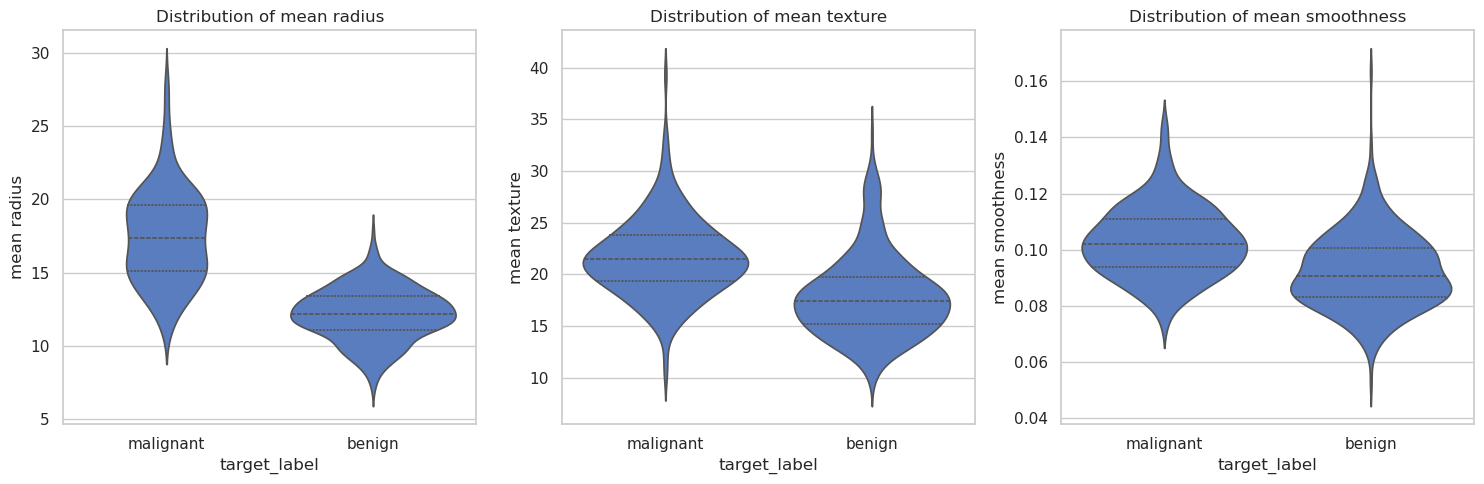

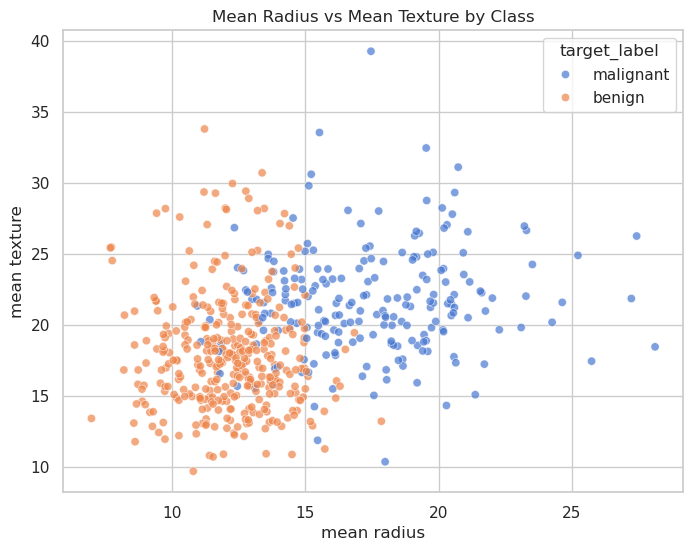

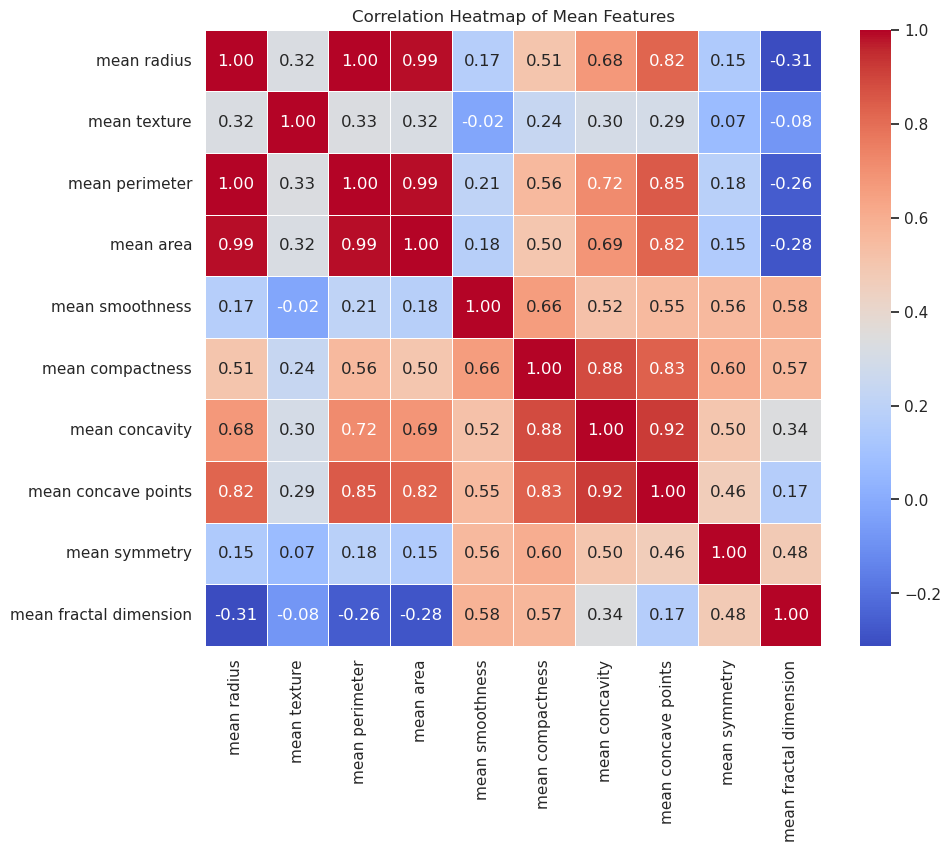

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 시각화 결과물을 저장할 디렉토리 환경 확인 (Zero Global Pollution 철학)
os.makedirs('../images', exist_ok=True)

# Seaborn 시각화 스타일 전역 설정
sns.set_theme(style="whitegrid", palette="muted")

#  Plot 1: Violin Plot (단변량 분포 및 밀도 시각화) 
features_to_plot = ['mean radius', 'mean texture', 'mean smoothness']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    # Box plot보다 데이터의 전체 분포(밀도)를 보여주기 유리한 Violin plot 채택
    sns.violinplot(x='target_label', y=feature, data=df, inner="quartile")
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.savefig('../images/violin_plots.png', dpi=300)
plt.show()

#  Plot 2: Scatter Plot (다변량 시각화를 통한 클래스 분리도 확인) 
plt.figure(figsize=(8, 6))
sns.scatterplot(x='mean radius', y='mean texture', hue='target_label', data=df, alpha=0.7)
plt.title('Mean Radius vs Mean Texture by Class')
plt.savefig('../images/scatter_radius_texture.png', dpi=300)
plt.show()

#  Plot 3: Correlation Heatmap (변수 간 상관관계 및 다중공선성 탐지) 
# 30개의 변수 중 해석을 용이하게 하기 위해 'mean'이 포함된 10개 변수만 추출
mean_cols = [col for col in df.columns if 'mean' in col]
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Heatmap of Mean Features')
plt.savefig('../images/correlation_heatmap.png', dpi=300)
plt.show()